## Importing the necessary libraries

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer # Ensure TfidfVectorizer is imported
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score

## Load the Dataset

In [8]:
dataset = pd.read_csv("/content/emails.csv")
dataset

,text,spam
0,Subject: naturally irresistible your corporate...,1
1,Subject: the stock trading gunslinger fanny i...,1
2,Subject: unbelievable new homes made easy im ...,1
3,Subject: 4 color printing special request add...,1
4,"Subject: do not have money , get software cds ...",1
...,...,...
5723,Subject: re : research and development charges...,0
5724,"Subject: re : receipts from visit jim , than...",0
5725,Subject: re : enron case study update wow ! a...,0
5726,"Subject: re : interest david , please , call...",0


## Understanding the Dataset

In [9]:
dataset.info   # Dataset Information

<bound method DataFrame.info of                                                    text  spam
0     Subject: naturally irresistible your corporate...     1
1     Subject: the stock trading gunslinger  fanny i...     1
2     Subject: unbelievable new homes made easy  im ...     1
3     Subject: 4 color printing special  request add...     1
4     Subject: do not have money , get software cds ...     1
...                                                 ...   ...
5723  Subject: re : research and development charges...     0
5724  Subject: re : receipts from visit  jim ,  than...     0
5725  Subject: re : enron case study update  wow ! a...     0
5726  Subject: re : interest  david ,  please , call...     0
5727  Subject: news : aurora 5 . 2 update  aurora ve...     0

[5728 rows x 2 columns]>

In [10]:
dataset.describe()  # Getting the Statistical Information

,spam
count,5728.000000
mean,0.238827
std,0.426404
min,0.000000
25%,0.000000
50%,0.000000
75%,0.000000
max,1.000000


## How many text are there in the dataset?

In [11]:
dataset["text"].count()
dataset

,text,spam
0,Subject: naturally irresistible your corporate...,1
1,Subject: the stock trading gunslinger fanny i...,1
2,Subject: unbelievable new homes made easy im ...,1
3,Subject: 4 color printing special request add...,1
4,"Subject: do not have money , get software cds ...",1
...,...,...
5723,Subject: re : research and development charges...,0
5724,"Subject: re : receipts from visit jim , than...",0
5725,Subject: re : enron case study update wow ! a...,0
5726,"Subject: re : interest david , please , call...",0


## Number of Spam email vs Ham email

In [12]:
dataset["spam"].value_counts()

,count
spam,
0,4360
1,1368


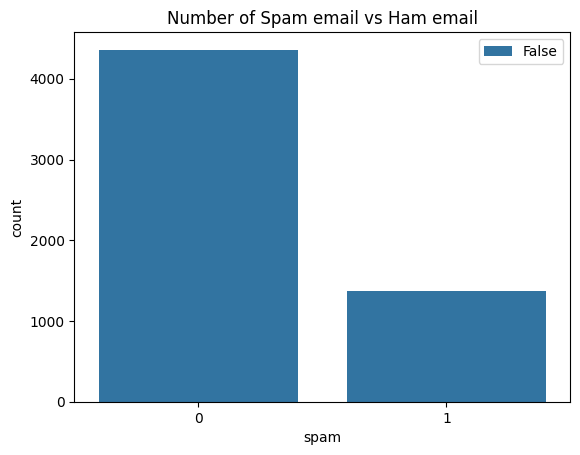

In [13]:
sns.countplot(x = "spam" , data = dataset)
plt.title("Number of Spam email vs Ham email")
plt.legend(["Ham" == 0 , "Spam" == 1])
plt.show()

## Vectorization : To convert the text data into numerical format.

In [14]:
vectorizer = TfidfVectorizer() # Initialize TfidfVectorizer
X = vectorizer.fit_transform(dataset["text"]) # Fit on raw text

## Split the dataset into train and test

In [15]:
X_train, X_test, y_train, y_test = train_test_split(X, dataset["spam"], test_size = 0.2)
X_train, X_test, y_train, y_test

(<Compressed Sparse Row sparse matrix of dtype 'float64'
 	with 563367 stored elements and shape (4582, 37303)>,
 <Compressed Sparse Row sparse matrix of dtype 'float64'
 	with 145013 stored elements and shape (1146, 37303)>,
 3993    0
 3308    0
 2233    0
 2219    0
 3618    0
        ..
 3826    0
 4870    0
 2608    0
 5710    0
 2779    0
 Name: spam, Length: 4582, dtype: int64,
 502     1
 767     1
 1175    1
 3824    0
 147     1
        ..
 431     1
 4934    0
 2802    0
 4422    0
 5576    0
 Name: spam, Length: 1146, dtype: int64)

## Train the Model

In [16]:
model = MultinomialNB()
model.fit(X_train, y_train)

MultinomialNB()

## Make Prediction

In [17]:
y_pred = model.predict(X_test)
y_pred

array([0, 1, 0, ..., 0, 0, 0])

## Evaluate the Model

In [18]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy : ", accuracy)

Accuracy :  0.8603839441535777


## Function to predict if a message is spam or not.

In [21]:
def predictMessage(message):
  messageVector = vectorizer.transform([message])
  prediction = model.predict(messageVector)
  return "Spam" if prediction[0] == 1 else "Ham"

In [22]:
userMessage = input("Enter text to predict : ")
prediction = predictMessage(userMessage)
print(f"The message is : {prediction}")


Enter text to predict : You are selected
The message is : Ham


In [26]:
import pickle
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB

# 1. Load your dataset
df = pd.read_csv("emails.csv")

# 2. Make sure you use the column containing the text (e.g., 'text' or 'message')
X = df['text'].astype(str).str.lower().str.strip()
y = df['spam'] # or your target label column

# 3. Initialize the vectorizer
vectorizer = TfidfVectorizer()

# 4. CRITICAL: Use fit_transform so the vectorizer learns the vocabulary!
X_vectorized = vectorizer.fit_transform(X)

# 5. Train your model
model = MultinomialNB()
model.fit(X_vectorized, y)

# 6. SAVE BOTH FILES NOW (Vectorizer now contains the fitted vocabulary)
with open('vectorizer.pkl', 'wb') as f:
    pickle.dump(vectorizer, f)

with open('EmailSpamDetector.pkl', 'wb') as f:
    pickle.dump(model, f)